## **Filtre passe-bas du premier ordre**

---



## Définir une fonction passe_bas(ω, ω₀) qui renvoie la fonction de transfert d'un passe-bas d'ordre 1 de pulsation de coupure ω₀.

Tracer son diagramme de Bode sur 2 décades avant et après $ω₀$ dans le cas où $f_0=\dfrac{ω₀}{2\pi}=\dfrac{1}{2\pi}$ kHz.

On indique qu'en Python:

- le nombre complexe mathématique $i$ tel que $i^2=-1$ s'écrit 1j et si l'on souhaite écrire $2i$, il faut noter 2j
- la commande abs(x) renvoie le module du nombre complexe x
- cmath.phase(x) renvoie son argument (après avoir chargé la bibliothèque cmath)
- la commande plt.semilogx() permet de tracer une fonction avec une abscisse logarithmique
- np.log(x) calcule le logarithme népérien (ou naturel), noté $\ln(x)$. Sa base est le nombre d'Euler, $e \approx 2.718$
- np.log10(x) calcule le logarithme en base 10, noté $\log_{10}(x)$.

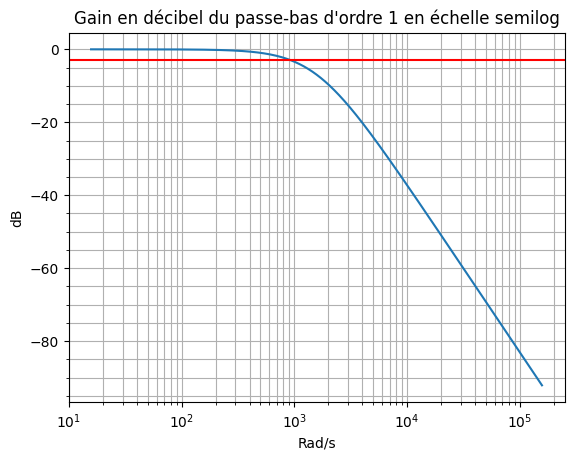

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fonction de transfert d'un passe bas d'ordre 1
def passe_bas(ω, ω0):
  return 1 / (1 + ω/ω0 * 1j)

# Définition de la pulsation de coupure
# R = 1kΩ et C = 1 μF
R = 1e3
C = 1e-6
ω0 = 1 / (R * C)

# Construction de la liste des pulsations pour le tracé
liste_ω = np.linspace(ω0 / 100, 100 * ω0, 10000)

# Construction par compréhension de la liste des gains en dB
Gain_dB_pb = [20 * np.log(abs(passe_bas(ω, ω0))) for ω in liste_ω]

# Tracé des graphiques
plt.subplot()
plt.title("Gain en décibel du passe-bas d'ordre 1 en échelle semilog")
plt.semilogx(liste_ω / 2*np.pi, Gain_dB_pb)
plt.xlabel("Rad/s")
plt.ylabel("dB")
plt.grid(which = 'both')
plt.minorticks_on()
# Affichage de la ligne à -3dB
plt.axhline(y = -3, color = 'r', linestyle = '-')
plt.show()

# Pour tracer la phase
from cmath import phase
# Construction par compréhension de la liste des phases
phase_deg_pb = [phase(passe_bas(ω, ω0)) for ω in liste_ω]
# À compléter
# __________________
# __________________
# __________________


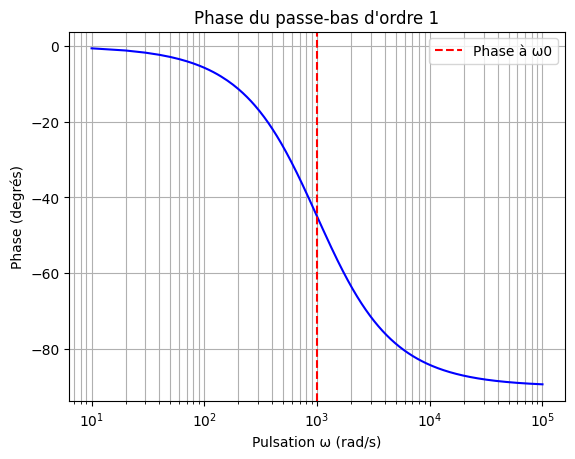

In [ ]:

# On multiplie par 180/pi pour plus de lisibilité sur le diagramme
phase_deg_pb = [np.degrees(phase(passe_bas(ω, ω0))) for ω in liste_ω]

# 2. Création de la figure pour la phase
plt.figure()
plt.semilogx(liste_ω, phase_deg_pb, color='blue')
plt.title("Phase du passe-bas d'ordre 1")
plt.xlabel("Pulsation ω (rad/s)")
plt.ylabel("Phase (degrés)")
plt.grid(which='both')
plt.axvline(x=1000, color='r', linestyle='--', label="Phase à ω0")
plt.legend()
plt.show()


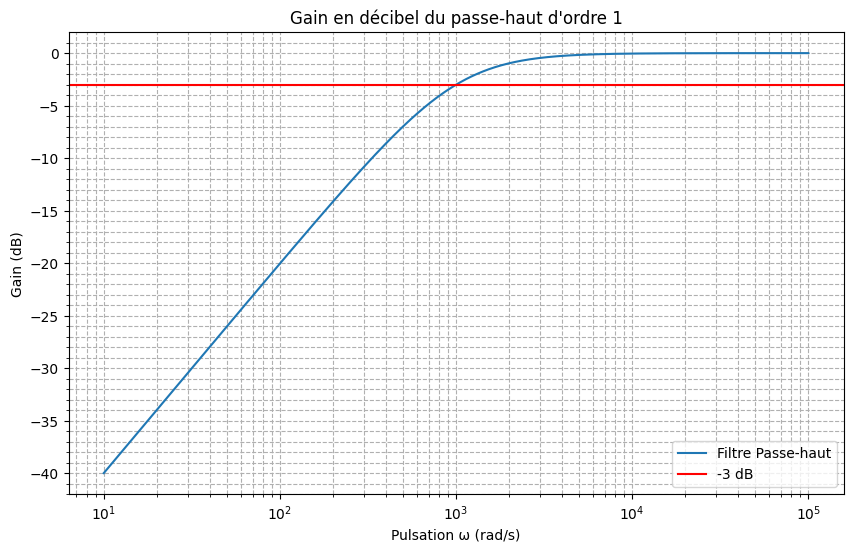

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def passe_haut(ω, ω0):
    return (1j * ω/ω0) / (1 + ω/ω0*1j)

# Définition de la pulsation de coupure
R = 1e3
C = 1e-6
ω0 = 1 / (R * C)

# Utilisation de logspace pour un meilleur rendu des points en échelle logarithmique
liste_ω = np.logspace(np.log10(ω0/100), np.log10(100*ω0), 1000)

Gain_dB_ph = [20 * np.log10(abs(passe_haut(ω, ω0))) for ω in liste_ω]

# Tracé du graphique
plt.figure(figsize=(10, 6))
plt.title("Gain en décibel du passe-haut d'ordre 1")
plt.semilogx(liste_ω, Gain_dB_ph, label="Filtre Passe-haut")
plt.xlabel("Pulsation ω (rad/s)")
plt.ylabel("Gain (dB)")
plt.grid(which = 'both', linestyle='--')
plt.minorticks_on()

# Affichage de la ligne à -3dB
plt.axhline(y = -3, color = 'r', linestyle = '-', label="-3 dB")
plt.legend()
plt.show()

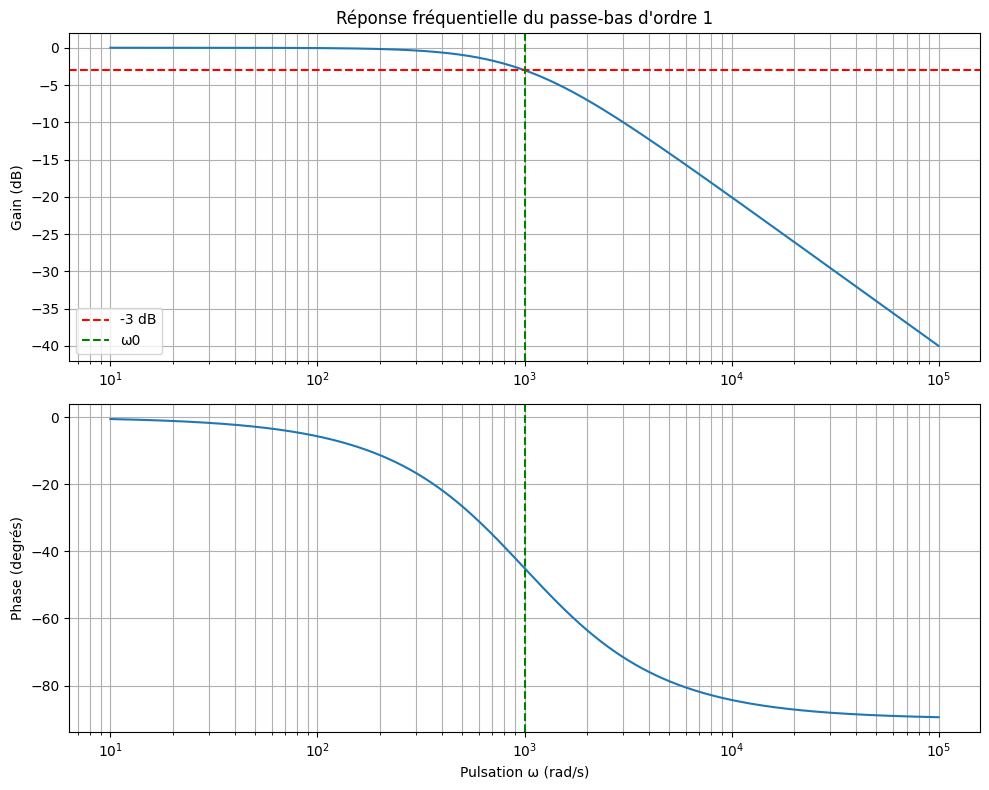

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cmath import phase

def passe_bas(ω, ω0):
    return 1 / (1 + 1j * ω / ω0)

R = 1e3
C = 1e-6
ω0 = 1 / (R * C)

# Utilisation de geomspace pour un meilleur rendu en échelle log
liste_ω = np.geomspace(ω0 / 100, 100 * ω0, 10000)

Gain_dB_pb = [20 * np.log10(abs(passe_bas(ω, ω0))) for ω in liste_ω]
phase_deg_pb = [np.degrees(phase(passe_bas(ω, ω0))) for ω in liste_ω]

# Tracé du Gain
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.semilogx(liste_ω, Gain_dB_pb) # On trace en fonction de ω pour correspondre à l'unité Rad/s
plt.title("Réponse fréquentielle du passe-bas d'ordre 1")
plt.ylabel("Gain (dB)")
plt.grid(which='both')
plt.axhline(y=-3, color='r', linestyle='--', label='-3 dB')
plt.axvline(x=ω0, color='g', linestyle='--', label='ω0')
plt.legend()

# Tracé de la Phase
plt.subplot(2, 1, 2)
plt.semilogx(liste_ω, phase_deg_pb)
plt.xlabel("Pulsation ω (rad/s)")
plt.ylabel("Phase (degrés)")
plt.grid(which='both')
plt.axvline(x=ω0, color='g', linestyle='--')

plt.tight_layout()
plt.show()

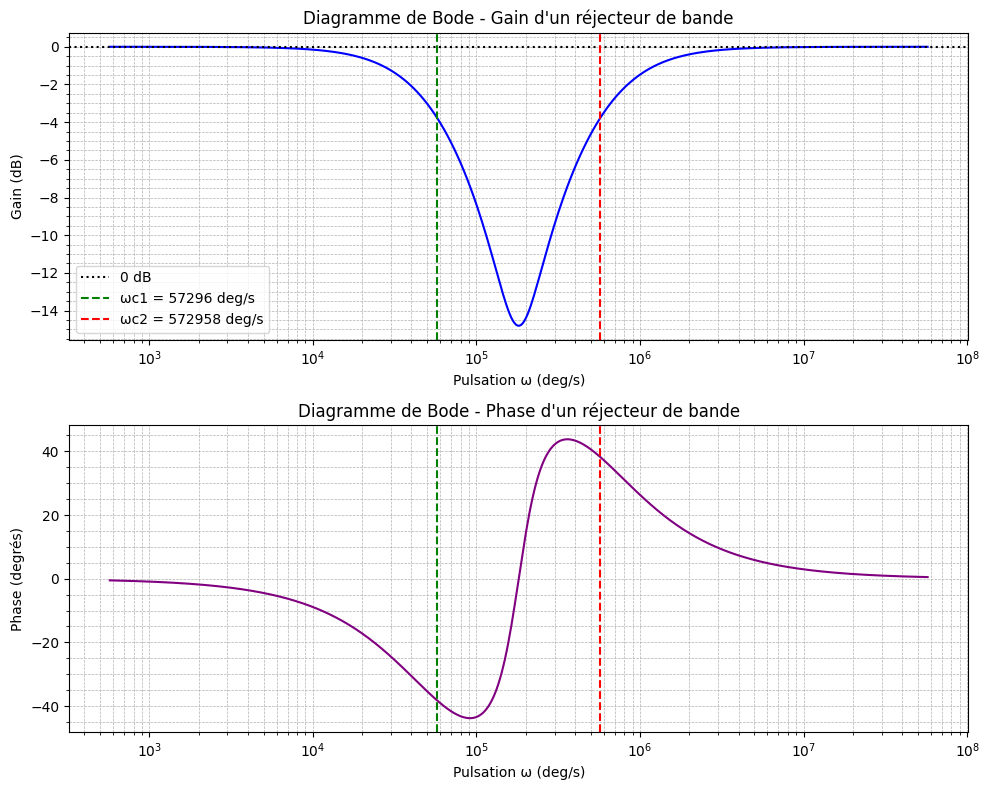

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cmath import phase

# Fonction de transfert d'un passe bas d'ordre 1 (pour construction du réjecteur)
def passe_bas_local(ω, ω0):
  return 1 / (1 + ω/ω0 * 1j)

# Fonction de transfert d'un passe haut d'ordre 1 (pour construction du réjecteur)
def passe_haut_local(ω, ω0):
  return (ω/ω0 * 1j) / (1 + ω/ω0 * 1j)

def rejeteur_bande(ω, ωc1, ωc2):
  return passe_bas_local(ω, ωc1) + passe_haut_local(ω, ωc2)

# Pour la pulsation de coupure basse (ωc1)
R1 = 1e3  # 1 kΩ
C1 = 1e-6 # 1 μF
ωc1 = 1 / (R1 * C1) # ~1000 rad/s

# Pour la pulsation de coupure haute (ωc2)
R2 = 100  # 100 Ω
C2 = 1e-6 # 1 μF
ωc2 = 1 / (R2 * C2) # ~10000 rad/s

# Assurer que ωc1 < ωc2 pour un filtre réjecteur de bande typique
if ωc1 >= ωc2:
    print(f"Attention : ωc1 ({ωc1:.2f} rad/s) devrait être inférieur à ωc2 ({ωc2:.2f} rad/s) pour un réjecteur de bande. Ajustement des valeurs.")
    ωc1_temp, ωc2_temp = ωc1, ωc2 # Sauvegarder les valeurs originales
    ωc1 = min(ωc1_temp, ωc2_temp)
    ωc2 = max(ωc1_temp, ωc2_temp)

liste_ω = np.logspace(np.log10(ωc1 / 100), np.log10(ωc2 * 100), 500)

# Convert angular frequency from rad/s to deg/s for plotting
liste_ω_dps = liste_ω * (180 / np.pi)
ωc1_dps = ωc1 * (180 / np.pi)
ωc2_dps = ωc2 * (180 / np.pi)

# Construction de la liste des gains en dB
Gain_dB_rb = [20 * np.log10(abs(rejeteur_bande(ω, ωc1, ωc2))) for ω in liste_ω]

# Construction de la liste des phases en degrés
phase_deg_rb = [np.degrees(phase(rejeteur_bande(ω, ωc1, ωc2))) for ω in liste_ω]

# --- Tracé des graphiques ---

plt.figure(figsize=(10, 8))

# Plot du Gain en décibels
plt.subplot(2, 1, 1)
plt.title("Diagramme de Bode - Gain d'un réjecteur de bande")
plt.semilogx(liste_ω_dps, Gain_dB_rb, color='blue') # Use converted list for x-axis
plt.xlabel("Pulsation ω (deg/s)") # Update x-axis label
plt.ylabel("Gain (dB)")
plt.grid(which = 'both', linestyle='--', linewidth=0.5)
plt.minorticks_on()
# Affichage des lignes de coupure et du niveau 0 dB
plt.axhline(y = 0, color = 'k', linestyle = ':', label="0 dB")
plt.axvline(x = ωc1_dps, color = 'green', linestyle = '--', label=f"ωc1 = {ωc1_dps:.0f} deg/s") # Use converted ωc1
plt.axvline(x = ωc2_dps, color = 'red', linestyle = '--', label=f"ωc2 = {ωc2_dps:.0f} deg/s") # Use converted ωc2
plt.legend()

# Plot de la Phase en degrés
plt.subplot(2, 1, 2)
plt.title("Diagramme de Bode - Phase d'un réjecteur de bande")
plt.semilogx(liste_ω_dps, phase_deg_rb, color='purple') # Use converted list for x-axis
plt.xlabel("Pulsation ω (deg/s)") # Update x-axis label
plt.ylabel("Phase (degrés)")
plt.grid(which = 'both', linestyle='--', linewidth=0.5)
plt.minorticks_on()
plt.axvline(x = ωc1_dps, color = 'green', linestyle = '--') # Use converted ωc1
plt.axvline(x = ωc2_dps, color = 'red', linestyle = '--') # Use converted ωc2

plt.tight_layout()
plt.show()
